<a href="https://colab.research.google.com/github/fruct49/ml_practice/blob/main/5.%20%D0%9A%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D1%8F%20%D1%82%D0%B5%D0%BA%D1%81%D1%82%D0%BE%D0%B2.%20%D0%9C%D0%B5%D1%82%D0%BE%D0%B4%20%D0%9D%D0%B0%D0%B8%D0%B2%D0%BD%D0%BE%D0%B3%D0%BE%20%D0%91%D0%B0%D0%B9%D0%B5%D1%81%D0%B0.%20%D0%9C%D0%B5%D1%82%D0%BE%D0%B4%20%D0%BE%D0%BF%D0%BE%D1%80%D0%BD%D1%8B%D1%85%20%D0%B2%D0%B5%D0%BA%D1%82%D0%BE%D1%80%D0%BE%D0%B2/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%967_%D0%9F%D1%80%D0%B8%D0%BC%D0%B5%D0%BD%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BC%D0%B5%D1%82%D0%BE%D0%B4%D0%BE%D0%B2_%D0%BC%D0%B0%D1%88%D0%B8%D0%BD%D0%BD%D0%BE%D0%B3%D0%BE_%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D1%8F_%D0%B4%D0%BB%D1%8F_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8_%D1%82%D0%B5%D0%BA%D1%81%D1%82%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №7. Применение методов машинного обучения для решения задач классификации текстов. Метод Наивного Байеса. Метод опорных векторов**

## Задание 0. Найдите в глобальной сети или соберите свой датасет для классификации текстов (Пример: новости -> рубрики, комментарии в соц. сетях -> характер, )

* Количество классов в датасете должно превышать 2
* Язык текста в датасете: русский

- ### Пример датасетов: [Russian Texts](https://www.kaggle.com/datasets?search=text+classification+russian)

### Загрузите датасет

Using Colab cache for faster access to the 'russian-social-media-text-classification' dataset.
Размер датасета: (38740, 3)

Первые 5 записей:
         oid      category                                               text
0  365271984  winter_sport  Волшебные фото Виктория Поплавская ЕвгенияМедв...
1  503385563       extreme  Возвращение в подземелье Треша 33 Эйфория тупо...
2  146016084      football  Лучшие чешские вратари – Доминик Доминатор Гаш...
3  933865449    boardgames  Rtokenoid Warhammer40k валрак решил нас подкор...
4  713550145        hockey  Шестеркин затаскивает Рейнджерс в финал Восточ...

Распределение классов:
category
autosport       3160
extreme         3110
martial_arts    3050
motosport       3030
boardgames      3020
tennis          3000
esport          2990
athletics       2970
hockey          2950
volleyball      2950
football        2860
basketball      2850
winter_sport    2800
Name: count, dtype: int64


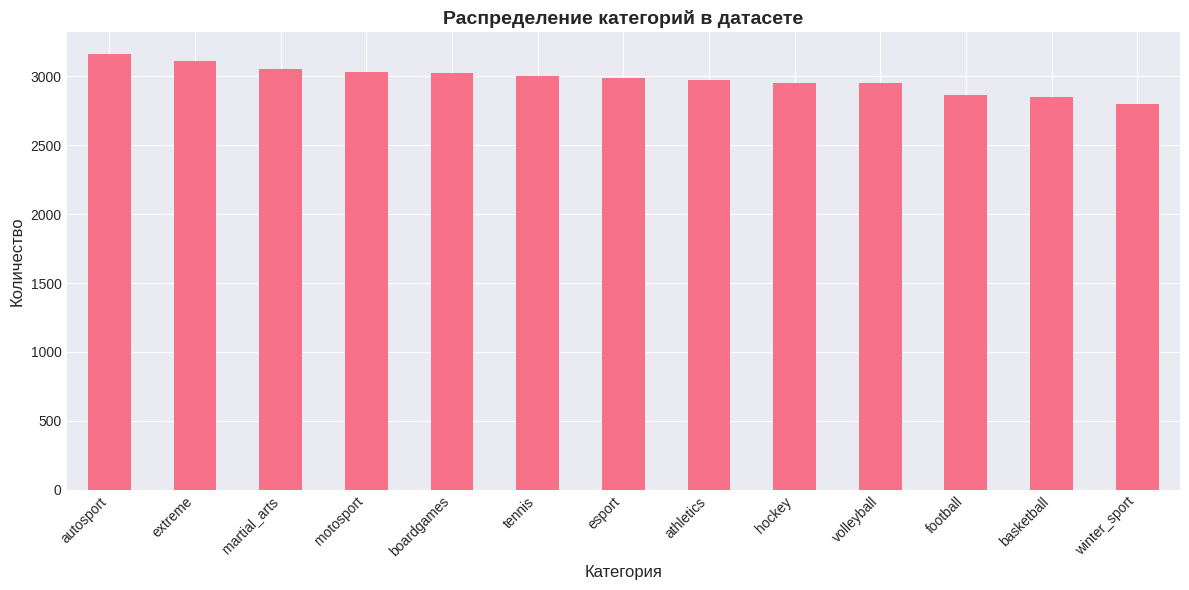


Всего классов: 13
Количество записей: 38740


In [6]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Загрузка датасета
df_train = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "mikhailma/russian-social-media-text-classification",
    "train.csv"
)

print("Размер датасета:", df_train.shape)
print("\nПервые 5 записей:")
print(df_train.head())
print("\nРаспределение классов:")
print(df_train['category'].value_counts())

# Визуализация распределения классов
plt.figure(figsize=(12, 6))
df_train['category'].value_counts().plot(kind='bar')
plt.title('Распределение категорий в датасете', fontsize=14, fontweight='bold')
plt.xlabel('Категория', fontsize=12)
plt.ylabel('Количество', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nВсего классов: {df_train['category'].nunique()}")
print(f"Количество записей: {len(df_train)}")

### Разделите данные на обучающую и валидационную выборки

In [7]:
from sklearn.model_selection import train_test_split

import re
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

russian_stopwords = stopwords.words('russian')

def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^а-яё\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_train['text_clean'] = df_train['text'].apply(preprocess_text)
df_train = df_train[df_train['text_clean'].str.len() > 0].reset_index(drop=True)

X = df_train['text_clean']
y = df_train['category']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Размер обучающей выборки: {len(X_train)}")
print(f"Размер валидационной выборки: {len(X_val)}")

Размер обучающей выборки: 30992
Размер валидационной выборки: 7748


### При выполении дальнейших заданий поэксперементируйте с методами векторизации текста:


1. [Bag of Words](https://habr.com/ru/companies/mlclass/articles/270591/) (BOW): Bag of Words представляет текст как вектор, где каждый элемент обозначает количество вхождений конкретного слова в тексте. Процесс включает в себя создание словаря всех уникальных слов в корпусе текстов и подсчет частоты встречаемости каждого слова в отдельных текстах.

2. [TF-IDF](https://habr.com/ru/companies/otus/articles/755772/) (Term Frequency-Inverse Document Frequency): TF-IDF учитывает не только количество вхождений слова в текст, но и частоту его встречаемости в других текстах. Он вычисляет вес слова, умножая его частоту встречаемости (term frequency) на обратную частоту документа (inverse document frequency). Это позволяет снизить вес наиболее часто встречающихся слов, которые могут быть менее информативными.

3. Word Embeddings (например, [Word2Vec](https://habr.com/ru/articles/446530/) и [GloVe](https://jonathan-hui.medium.com/nlp-word-embedding-glove-5e7f523999f6)): Word Embeddings используют нейронные сети для создания векторных представлений слов, которые учитывают семантическую близость между словами. Нейронные сети обучаются на больших текстовых корпусах и захватывают семантические отношения между словами, что позволяет представить слова в векторном пространстве.

4. One-Hot Encoding: One-Hot Encoding преобразует каждое слово в уникальный вектор, где все элементы равны нулю, за исключением одного, который равен единице. Каждый вектор соответствует отдельному слову и используется для представления его в пространстве признаков.

5. [Count Vectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html): Count Vectorizer подсчитывает количество раз, которое каждое слово встречается в тексте. Он создает вектор, в котором каждый элемент соответствует количеству вхождений конкретного слова в текст.

6. [Hashing Vectorizer](https://kavita-ganesan.com/hashingvectorizer-vs-countvectorizer/): Hashing Vectorizer преобразует каждое слово в уникальный числовой идентификатор с помощью хеширования. Он использует хеш-функцию для преобразования слова в числовое значение, которое затем используется в векторном представлении.

7. [Doc2Vec](https://habr.com/ru/articles/599513/): Doc2Vec является расширением метода Word2Vec и позволяет получить векторное представление не только отдельных слов, но и целых документов или текстов. Алгоритм обучает нейронную сеть, которая учитывает контекст и порядок слов в предложении, чтобы получить векторное представление документа. Это позволяет сравнивать и измерять семантическую близость между целыми текстовыми документами.

1. Bag of Words...
   Точность: 0.7463

2. TF-IDF...
   Точность: 0.7847

3. TF-IDF с n-граммами (1-3)...
   Точность: 0.8037

4. Hashing Vectorizer...
   Точность: 0.7136



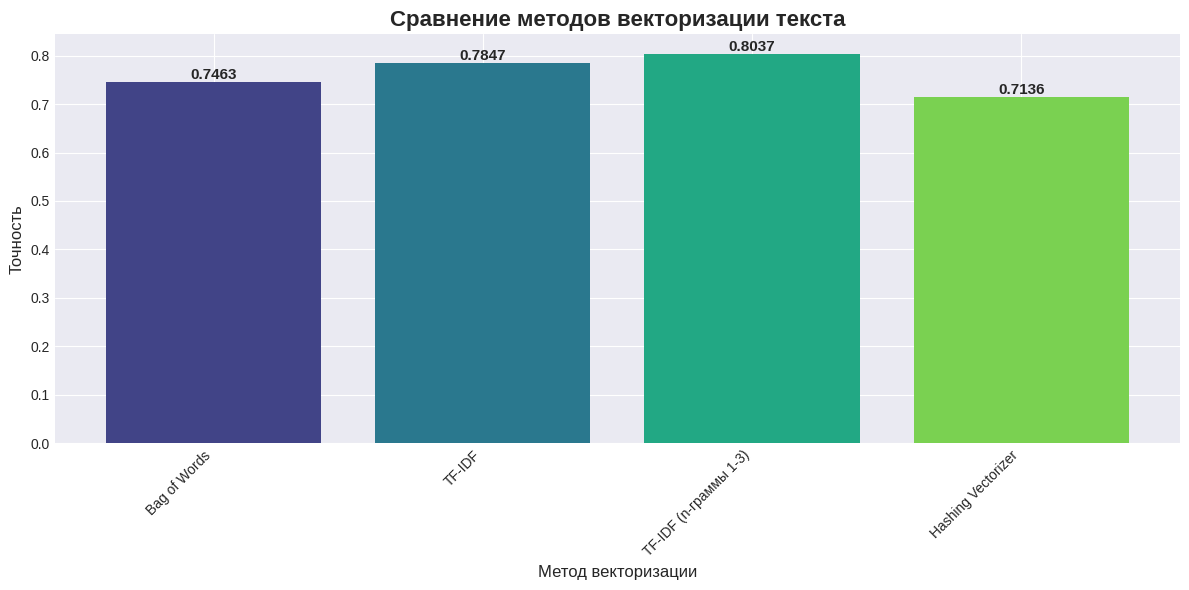

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

vectorization_results = {}

# 1. Bag of Words (CountVectorizer)
print("1. Bag of Words...")
bow_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(max_features=10000, ngram_range=(1,2), stop_words=russian_stopwords)),
    ('classifier', LinearSVC(C=1.0, random_state=42, max_iter=2000))
])
bow_pipeline.fit(X_train, y_train)
bow_acc = accuracy_score(y_val, bow_pipeline.predict(X_val))
vectorization_results['Bag of Words'] = bow_acc
print(f"   Точность: {bow_acc:.4f}\n")

# 2. TF-IDF
print("2. TF-IDF...")
tfidf_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(max_features=10000, ngram_range=(1,2), stop_words=russian_stopwords)),
    ('classifier', LinearSVC(C=1.0, random_state=42, max_iter=2000))
])
tfidf_pipeline.fit(X_train, y_train)
tfidf_acc = accuracy_score(y_val, tfidf_pipeline.predict(X_val))
vectorization_results['TF-IDF'] = tfidf_acc
print(f"   Точность: {tfidf_acc:.4f}\n")

# 3. TF-IDF с биграммами и триграммами
print("3. TF-IDF с n-граммами (1-3)...")
tfidf_ngram_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(max_features=15000, ngram_range=(1,3), stop_words=russian_stopwords)),
    ('classifier', LinearSVC(C=1.0, random_state=42, max_iter=2000))
])
tfidf_ngram_pipeline.fit(X_train, y_train)
tfidf_ngram_acc = accuracy_score(y_val, tfidf_ngram_pipeline.predict(X_val))
vectorization_results['TF-IDF (n-граммы 1-3)'] = tfidf_ngram_acc
print(f"   Точность: {tfidf_ngram_acc:.4f}\n")

# 4. HashingVectorizer
print("4. Hashing Vectorizer...")
from sklearn.feature_extraction.text import HashingVectorizer
hash_pipeline = Pipeline([
    ('vectorizer', HashingVectorizer(n_features=10000, ngram_range=(1,2))),
    ('classifier', LinearSVC(C=1.0, random_state=42, max_iter=2000))
])
hash_pipeline.fit(X_train, y_train)
hash_acc = accuracy_score(y_val, hash_pipeline.predict(X_val))
vectorization_results['Hashing Vectorizer'] = hash_acc
print(f"   Точность: {hash_acc:.4f}\n")

# Визуализация сравнения методов векторизации
plt.figure(figsize=(12, 6))
bars = plt.bar(vectorization_results.keys(), vectorization_results.values(),
               color=sns.color_palette('viridis', len(vectorization_results)))
plt.title('Сравнение методов векторизации текста', fontsize=16, fontweight='bold')
plt.xlabel('Метод векторизации', fontsize=12)
plt.ylabel('Точность', fontsize=12)
plt.xticks(rotation=45, ha='right')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

#### Оцените влияние разных методов на конечный результат

## Задание 1. Обучите модель классификатора Naive Bayes для решения поставленной задачи, используя пайплайн и подбор оптимальных параметров

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Обучение модели с подбором параметров
nb_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('classifier', MultinomialNB())
])

nb_params = {
    'vectorizer__max_features': [5000, 10000],
    'vectorizer__ngram_range': [(1, 1), (1, 2)],
    'vectorizer__min_df': [2, 5],
    'vectorizer__max_df': [0.8, 0.9],
    'classifier__alpha': [0.1, 0.5, 1.0]
}

nb_grid = GridSearchCV(nb_pipeline, nb_params, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)
nb_grid.fit(X_train, y_train)

print(f"Лучшие параметры: {nb_grid.best_params_}")
print(f"Лучшая точность на кросс-валидации: {nb_grid.best_score_:.4f}")

# Оценка точности
from sklearn.metrics import accuracy_score
y_pred_nb = nb_grid.best_estimator_.predict(X_val)
nb_accuracy = accuracy_score(y_val, y_pred_nb)
print(f"\nТочность на валидационной выборке: {nb_accuracy:.4f} ({nb_accuracy*100:.2f}%)")

Fitting 3 folds for each of 48 candidates, totalling 144 fits


### Вывод матрицы ошибок:

In [ ]:
cm_nb = confusion_matrix(y_val, y_pred_nb)
plt.figure(figsize=(14, 12))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_val.unique()),
            yticklabels=sorted(y_val.unique()))
plt.title('Матрица ошибок - Naive Bayes', fontsize=16, fontweight='bold')
plt.ylabel('Истинный класс', fontsize=12)
plt.xlabel('Предсказанный класс', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nДетальный отчет по классам:")
print(classification_report(y_val, y_pred_nb, zero_division=0))

### Оценка точности:

In [ ]:
# Ваш код

## Задание 2. Обучите модель SVM (метод опорных векторов) для решения поставленной задачи, используя пайплайны и подбор оптимальных параметров

In [ ]:
# Ваш код

### Вывод матрицы ошибок:

In [ ]:
# Ваш код

### Оценка точности:

In [ ]:
# Ваш код

## Задание 3. Обучите модель классификатора Decision Tree Classifier для решения поставленной задачи

In [ ]:
# Ваш код

### Вывод матрицы ошибок:

In [ ]:
# Ваш код

### Оценка точности:

In [ ]:
# Ваш код

## Задание 4. Обучите модель классификатора Random Forest Classifier для решения поставленной задачи

In [ ]:
# Ваш код

### Вывод матрицы ошибок:

In [ ]:
# Ваш код

### Оценка точности:

In [ ]:
# Ваш код

## Подведите общие итоги и сделайте выводы

In [ ]:
# Ваш код

      Ваши выводы